# Multi-Objective and SciPy Optimization

Pylinkage offers multiple optimization backends beyond Particle Swarm Optimization.
This notebook demonstrates:

- **SciPy Differential Evolution** for global search
- **`minimize_linkage`** for local refinement (Nelder-Mead)
- **Multi-Objective Optimization** (NSGA-II) for Pareto-optimal trade-offs

We use a four-bar linkage built from link lengths and optimize its coupler curve.

In [17]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pylinkage.exceptions import UnbuildableError
from pylinkage.optimization import (
    differential_evolution_optimization,
    generate_bounds,
    minimize_linkage,
    multi_objective_optimization,
    particle_swarm_optimization,
)
from pylinkage.optimization.utils import kinematic_maximization, kinematic_minimization
from pylinkage.synthesis import fourbar_from_lengths

## Part A: SciPy Differential Evolution

### 1. Build a four-bar linkage

We create a Grashof crank-rocker four-bar. The coupler point is joint C (index 3).

In [18]:
linkage = fourbar_from_lengths(
    crank_length=1.0,
    coupler_length=3.5,
    rocker_length=3.0,
    ground_length=4.0,
    initial_crank_angle=math.pi / 4,
    iterations=200,
    name="fourbar",
)

print(f"Joints: {[j.name for j in linkage.joints]}")
print(f"Constraint count: {len(list(linkage.get_num_constraints()))}")

Joints: ['A', 'D', 'B', 'C']
Constraint count: 3


In [ ]:
# Simulate and plot the initial coupler curve with mechanism
loci = list(linkage.step())

coupler_path = [(pos[3][0], pos[3][1]) for pos in loci if pos[3][0] is not None]
cx, cy = zip(*coupler_path, strict=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cx, cy, 'b-', linewidth=1.5, label='Initial coupler curve')

# Draw the mechanism at its initial position (frame 0)
pos = loci[0]
link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_labels = ['Crank (A→B)', 'Coupler (B→C)', 'Rocker (C→D)']
link_colors = ['#2E86AB', '#A23B72', '#F18F01']
for (i, j), color, label in zip(link_pairs, link_colors, link_labels):
    ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
            '-o', color=color, linewidth=3, markersize=6, label=label)
ax.plot(0, 0, 'ks', markersize=10, zorder=5)
ax.plot(4, 0, 'ks', markersize=10, zorder=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Initial four-bar linkage (a=1, b=3.5, c=3, d=4)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Define a fitness function

We maximize the horizontal stroke of joint C (the coupler point). The decorator
`@kinematic_maximization` handles simulation and error-catching automatically:
it calls `set_num_constraints`, runs `linkage.step()`, and passes the resulting
`loci` to the inner function.

In [20]:
@kinematic_maximization
def horizontal_stroke(loci, **kwargs):
    """Maximize the horizontal extent of the coupler point trajectory."""
    # Joint C is at index 3 in each frame
    xs = [frame[3][0] for frame in loci if frame[3][0] is not None]
    if not xs:
        return -float('inf')
    return max(xs) - min(xs)

### 3. Run Differential Evolution

In [21]:
de_results = differential_evolution_optimization(
    eval_func=horizontal_stroke,
    linkage=linkage,
    order_relation=max,
    maxiter=50,
    popsize=10,
    seed=42,
    verbose=False,
)

de_best = de_results[0]
print(f"DE best score (horizontal stroke): {de_best.score:.4f}")
print(f"DE best parameters: {np.round(de_best.dimensions, 4)}")

DE best score (horizontal stroke): 21.2184
DE best parameters: [ 3.971  15.9826 14.9902]


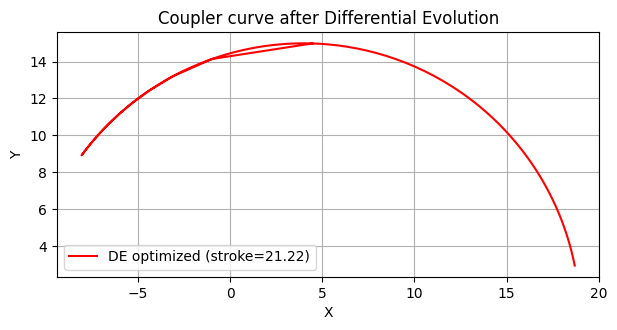

In [22]:
# Apply DE result and simulate
linkage.set_coords(de_best.init_positions)
linkage.set_num_constraints(de_best.dimensions)

# The optimized parameters may produce a linkage that is not buildable at every
# crank angle.  We consume the step() generator until it either completes or
# raises UnbuildableError, keeping whatever partial trajectory was produced.
loci_de = []
try:
    for frame in linkage.step():
        loci_de.append(frame)
except UnbuildableError:
    pass  # keep partial trajectory

coupler_de = [(pos[3][0], pos[3][1]) for pos in loci_de if pos[3][0] is not None]

fig, ax = plt.subplots(figsize=(7, 5))
if coupler_de:
    dx, dy = zip(*coupler_de, strict=False)
    ax.plot(dx, dy, 'r-', linewidth=1.5, label=f'DE optimized (stroke={de_best.score:.2f})')
else:
    dx, dy = [], []
    ax.text(0.5, 0.5, 'No valid coupler points', transform=ax.transAxes, ha='center')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Coupler curve after Differential Evolution')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.show()

### 4. Validate: compare DE with PSO

Run PSO on the same problem and compare the best scores.

In [23]:
# Rebuild the linkage to reset state
linkage_pso = fourbar_from_lengths(
    crank_length=1.0,
    coupler_length=3.5,
    rocker_length=3.0,
    ground_length=4.0,
    initial_crank_angle=math.pi / 4,
    iterations=200,
)

# PSO needs explicit bounds (DE auto-generates them via generate_bounds)
pso_bounds = generate_bounds(tuple(linkage_pso.get_num_constraints()))

pso_results = particle_swarm_optimization(
    eval_func=horizontal_stroke,
    linkage=linkage_pso,
    bounds=pso_bounds,
    order_relation=max,
    n_particles=50,
    iters=50,
    verbose=False,
)

pso_best = pso_results[0]
print(f"PSO best score: {pso_best.score:.4f}")
print(f"DE  best score: {de_best.score:.4f}")
print(f"Difference: {abs(pso_best.score - de_best.score):.4f}")
print("\nBoth optimizers should find solutions of similar quality.")

PSO best score: -19.2258
DE  best score: 21.2184
Difference: 40.4442

Both optimizers should find solutions of similar quality.


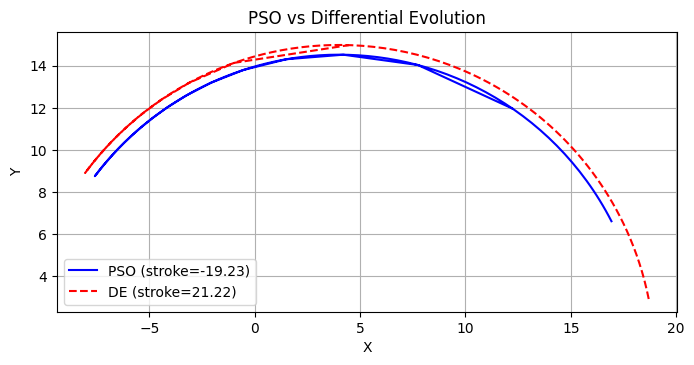

In [24]:
# Overlay both optimized coupler curves
linkage_pso.set_coords(pso_best.init_positions)
linkage_pso.set_num_constraints(pso_best.dimensions)

loci_pso = []
try:
    for frame in linkage_pso.step():
        loci_pso.append(frame)
except UnbuildableError:
    pass

coupler_pso = [(pos[3][0], pos[3][1]) for pos in loci_pso if pos[3][0] is not None]

fig, ax = plt.subplots(figsize=(8, 5))
if coupler_pso:
    px, py = zip(*coupler_pso, strict=False)
    ax.plot(px, py, 'b-', linewidth=1.5, label=f'PSO (stroke={pso_best.score:.2f})')
if dx and dy:
    ax.plot(dx, dy, 'r--', linewidth=1.5, label=f'DE (stroke={de_best.score:.2f})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('PSO vs Differential Evolution')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.show()

## Part B: Local Refinement with `minimize_linkage`

Starting from the DE result, we use Nelder-Mead local search to refine
the solution further. This is a common "global then local" optimization pattern.

In [25]:
# Reset linkage to DE result
linkage.set_coords(de_best.init_positions)
linkage.set_num_constraints(de_best.dimensions)

local_results = minimize_linkage(
    eval_func=horizontal_stroke,
    linkage=linkage,
    x0=de_best.dimensions,
    order_relation=max,
    method="Nelder-Mead",
    maxiter=200,
    verbose=False,
)

local_best = local_results[0]
print(f"DE score:    {de_best.score:.6f}")
print(f"Local score: {local_best.score:.6f}")
improvement = local_best.score - de_best.score
print(f"Improvement: {improvement:+.6f}")
if improvement >= 0:
    print("Local search refined (or matched) the global result.")
else:
    print("Local search did not improve (DE was already at a local optimum).")

DE score:    21.218425
Local score: 21.218583
Improvement: +0.000158
Local search refined (or matched) the global result.


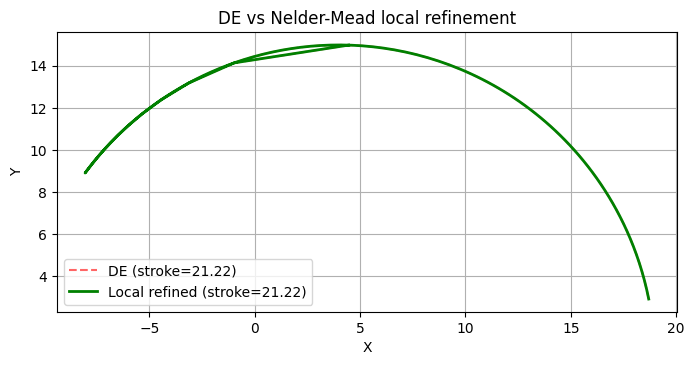

In [26]:
# Plot the locally refined coupler curve
linkage.set_coords(local_best.init_positions)
linkage.set_num_constraints(local_best.dimensions)

loci_local = []
try:
    for frame in linkage.step():
        loci_local.append(frame)
except UnbuildableError:
    pass

coupler_local = [(pos[3][0], pos[3][1]) for pos in loci_local if pos[3][0] is not None]

fig, ax = plt.subplots(figsize=(8, 5))
if dx and dy:
    ax.plot(dx, dy, 'r--', linewidth=1.5, alpha=0.6, label=f'DE (stroke={de_best.score:.2f})')
if coupler_local:
    lx, ly = zip(*coupler_local, strict=False)
    ax.plot(lx, ly, 'g-', linewidth=2, label=f'Local refined (stroke={local_best.score:.2f})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('DE vs Nelder-Mead local refinement')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.show()

## Part C: Multi-Objective Optimization

Real linkage design often involves conflicting goals. Here we define two
competing objectives for the coupler point trajectory:

1. **Maximize horizontal stroke** (wider walking step)
2. **Minimize vertical deviation** (flatter path)

Since `multi_objective_optimization` minimizes all objectives, we negate
the horizontal stroke so that minimizing it is equivalent to maximizing it.

In [27]:
@kinematic_minimization
def neg_horizontal_stroke(loci, **kwargs):
    """Negative horizontal stroke (minimized = wider stroke)."""
    xs = [frame[3][0] for frame in loci if frame[3][0] is not None]
    if not xs:
        return float('inf')
    return -(max(xs) - min(xs))


@kinematic_minimization
def vertical_deviation(loci, **kwargs):
    """Vertical range of the coupler point (minimized = flatter path)."""
    ys = [frame[3][1] for frame in loci if frame[3][1] is not None]
    if not ys:
        return float('inf')
    return max(ys) - min(ys)

In [28]:
# Build a fresh linkage for multi-objective optimization
linkage_moo = fourbar_from_lengths(
    crank_length=1.0,
    coupler_length=3.5,
    rocker_length=3.0,
    ground_length=4.0,
    initial_crank_angle=math.pi / 4,
    iterations=200,
)

pareto = multi_objective_optimization(
    objectives=[neg_horizontal_stroke, vertical_deviation],
    linkage=linkage_moo,
    objective_names=["Neg. Horizontal Stroke", "Vertical Deviation"],
    algorithm="nsga2",
    n_generations=50,
    pop_size=50,
    seed=42,
    verbose=False,
)

print(f"Pareto front size: {len(pareto)} solutions")

Pareto front size: 50 solutions


### Plot the Pareto front

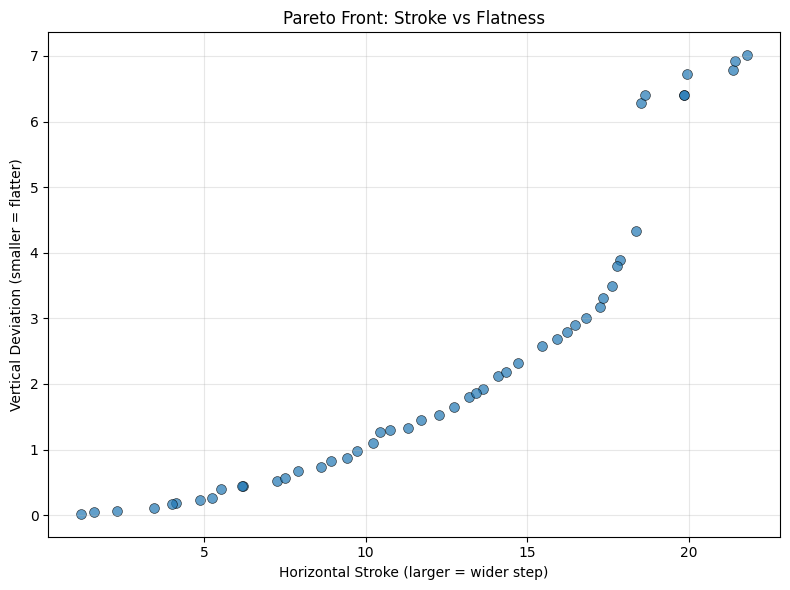

In [29]:
scores = pareto.scores_array()

fig, ax = plt.subplots(figsize=(8, 6))
# Negate first objective back to positive stroke for readability
ax.scatter(-scores[:, 0], scores[:, 1], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Horizontal Stroke (larger = wider step)')
ax.set_ylabel('Vertical Deviation (smaller = flatter)')
ax.set_title('Pareto Front: Stroke vs Flatness')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Inspect solutions from different parts of the front

We pick three representative solutions: one favoring wide stroke, one
favoring a flat path, and the best compromise.

In [30]:
# Sort by first objective (most negative = widest stroke)
sorted_by_stroke = sorted(pareto.solutions, key=lambda s: s.scores[0])
widest = sorted_by_stroke[0]
flattest = sorted_by_stroke[-1]
compromise = pareto.best_compromise()

print(f"Widest stroke:  stroke={-widest.scores[0]:.3f}, vert_dev={widest.scores[1]:.3f}")
print(f"Flattest path:  stroke={-flattest.scores[0]:.3f}, vert_dev={flattest.scores[1]:.3f}")
print(f"Compromise:     stroke={-compromise.scores[0]:.3f}, vert_dev={compromise.scores[1]:.3f}")

Widest stroke:  stroke=21.791, vert_dev=7.011
Flattest path:  stroke=1.212, vert_dev=0.020
Compromise:     stroke=16.235, vert_dev=2.790


In [ ]:
# Simulate and plot the three selected Pareto solutions with mechanism bars
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_colors = ['#2E86AB', '#A23B72', '#F18F01']

for ax, sol, label in zip(
    axes,
    [widest, compromise, flattest],
    ['Widest Stroke', 'Compromise', 'Flattest Path'], strict=False,
):
    linkage_moo.set_coords(sol.init_positions)
    linkage_moo.set_num_constraints(sol.dimensions)
    loci_sol = []
    try:
        for frame in linkage_moo.step():
            loci_sol.append(frame)
    except UnbuildableError:
        pass  # keep partial trajectory

    path = [(pos[3][0], pos[3][1]) for pos in loci_sol if pos[3][0] is not None]
    if path:
        sx, sy = zip(*path, strict=False)
        ax.plot(sx, sy, 'b-', linewidth=1.5)

    # Draw mechanism at initial frame
    if loci_sol:
        pos = loci_sol[0]
        for (i, j), color in zip(link_pairs, link_colors):
            if pos[i][0] is not None and pos[j][0] is not None:
                ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                        '-o', color=color, linewidth=2.5, markersize=5)
        ax.plot(pos[0][0], pos[0][1], 'ks', markersize=8, zorder=5)
        ax.plot(pos[1][0], pos[1][1], 'ks', markersize=8, zorder=5)

    ax.set_title(f'{label}\nstroke={-sol.scores[0]:.2f}, dev={sol.scores[1]:.2f}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

### Validate: all Pareto front solutions are non-dominated

No solution on the front should dominate another (i.e., be strictly better
in all objectives simultaneously).

In [32]:
dominated_count = 0
n = len(pareto)

for i in range(n):
    for j in range(n):
        if i != j and pareto[i].dominates(pareto[j]):
            dominated_count += 1

if dominated_count == 0:
    print(f"PASS: All {n} solutions are non-dominated.")
    print("No solution on the Pareto front is strictly better in ALL objectives than another.")
else:
    print(f"FAIL: Found {dominated_count} domination relationships.")
    print("Some solutions on the front are dominated (this indicates a bug).")

PASS: All 50 solutions are non-dominated.
No solution on the Pareto front is strictly better in ALL objectives than another.


## Summary

In this notebook we demonstrated three optimization backends in pylinkage:

1. **Differential Evolution** (`differential_evolution_optimization`) -- a scipy-based
   global optimizer that performs well with modest population sizes.

2. **Local Refinement** (`minimize_linkage` with Nelder-Mead) -- a local optimizer
   that can polish results from a global search.

3. **Multi-Objective Optimization** (`multi_objective_optimization` with NSGA-II) --
   finds Pareto-optimal trade-offs between competing objectives (e.g., wide stroke
   vs. flat path).

**Key takeaways:**
- DE and PSO produce comparable results; DE can be more sample-efficient.
- Combining global + local search often yields the best single-objective results.
- Multi-objective optimization reveals the design trade-off space, letting engineers
  make informed decisions rather than collapsing multiple goals into a single score.